In [1]:
from astropy.time import Time
from sunpy.coordinates import get_body_heliographic_stonyhurst
import matplotlib.pyplot as plt
import numpy as np

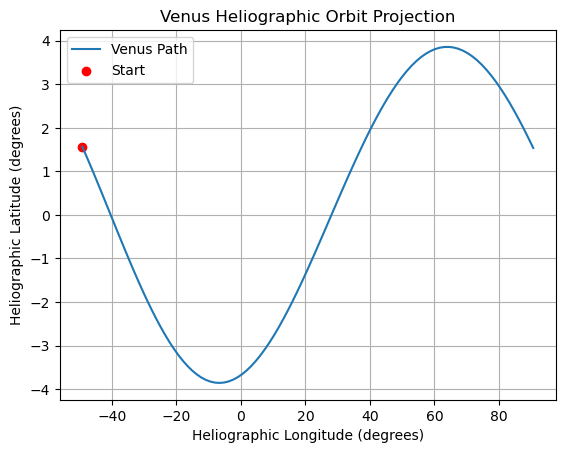

In [2]:
#define the time range for the simulation (e.g., one Venus year)
times = Time('2025-01-01') + np.linspace(0, 225, 100) # ~225 days for Venus year

#compute Venus position over time
venus_coords = [get_body_heliographic_stonyhurst('venus', time=t) for t in times]

#Extract longitude and latitude
longs = [coord.lon.to('deg').value for coord in venus_coords]
lats = [coord.lat.to('deg').value for coord in venus_coords]

#Plotting
plt.figure()#figsize=(10, 6)
plt.plot(longs, lats, label='Venus Path')
plt.scatter(longs[0], lats[0], color='red', label='Start')
plt.title('Venus Heliographic Orbit Projection')
plt.xlabel('Heliographic Longitude (degrees)')
plt.ylabel('Heliographic Latitude (degrees)')
plt.grid(True)
plt.legend()
plt.show()


In [3]:
from skyfield.api import load
from skyfield.api import N,S,E,W, wgs84
from skyfield.almanac import find_discrete, sunrise_sunset
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#Time and Location
ts = load.timescale()
t0 = ts.utc(2025, 1, 1)
t1 = ts.utc(2026, 1, 1)

In [6]:
#Ephemeris and Observer
eph = load('de421.bsp')
sun = eph['Sun']
venus = eph['Venus']
earth = eph['Earth']
observer = earth +  wgs84.latlon(17.4 * N, 83.2 * E, elevation_m=45) #visakhapatnam

In [7]:
#Calculate Position over Time (Daily steps)
days = np.linspace(0, t1-t0, 365)
t = ts.utc(2025, 1, 1, days)
astro = observer.at(t).observe(venus)
alt, az, distance = astro.apparent().altaz()

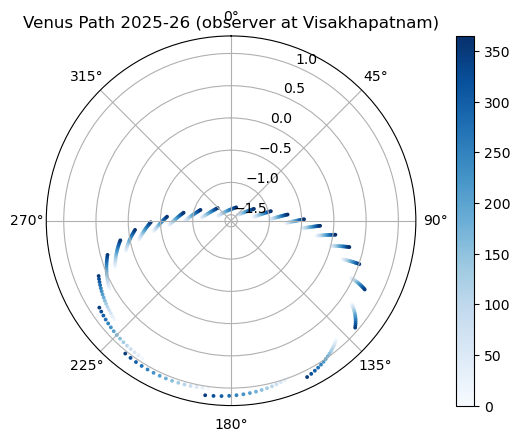

In [8]:
#Plotting with Matplotlib
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
#convert az to radians, invert polar plot
points = ax.scatter(az.radians, alt.radians, s= 3, c=days, cmap='Blues')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
#ax.set_ylim(0, 90) # Elevation 0-90
plt.title('Venus Path 2025-26 (observer at Visakhapatnam)')
ax.figure.colorbar(points, pad = 0.08)
plt.show()


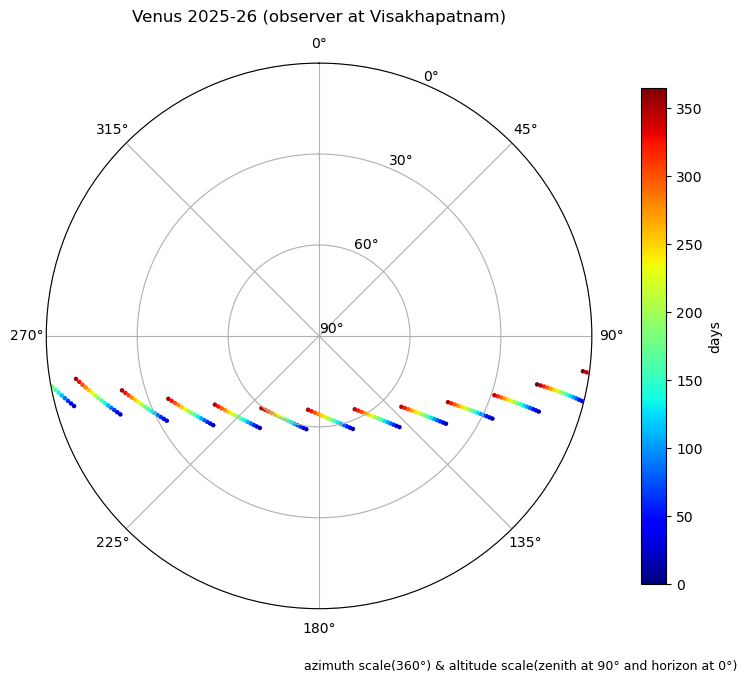

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

#North at the top, clockwise rotation
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

#Convert azimuth to radians and altitude to radial distance from zenith
theta = az.radians
r = 90 - alt.degrees   # Zenith distance 

#Filter for points above the horizon (alt > 0)
#mask = alt.degrees > 0 and use theta[mask], r[mask]
points = ax.scatter(theta, r, label='Venus Path', s= 5, c=days, cmap='jet')

#Configure labels to show altitude degrees instead of radial distance
ax.set_ylim(0, 90)
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels(['90°', '60°','30°','0°']) # Zenith (0 distance) to Horizon (90)

ax.set_title("Venus 2025-26 (observer at Visakhapatnam)", pad=30)
ax.figure.colorbar(points, pad = 0.08, label = 'days', fraction = 0.04)
ax.text(x = 110, y = 110, s = 'azimuth scale(360°) & altitude scale(zenith at 90° and horizon at 0°)', size = 9)
plt.show()
